In [1]:
from pyHepMC3 import HepMC3 as hm3
import pyNuHepMC as nhm
import pyProSelecta as ps

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sp

In [7]:
%pip install -U numpy


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
rdr = nhm.Reader("neut.EDRMF.DCC5D.MicroBooNE.250000Ev.hepmc3.gz")

In [4]:
!bash zcat "neut.EDRMF.DCC5D.MicroBooNE.250000Ev.hepmc3.gz" | head -244

HepMC::Version 3.03.01
HepMC::Asciiv3-START_EVENT_LISTING
W CV
T NEUT\|6.2.0\|https://doi.org/10.1140/epjs/s11734-021-00287-7
A NuHepMC.Beam.EnergyUnit GEV
A NuHepMC.Beam.RateUnit #frac{Number of #nu_{#mu}}{1.592 #upoint 10^{20} POT cm^{2} 0.05 GeV}
A NuHepMC.Beam.Type Histogram
A NuHepMC.Beam[14].Histogram.BinContent 24627200.000000 94533000.000000 122210496.000000 145618000.000000 180872496.000000 199318496.000000 213119008.000000 223194496.000000 236011488.000000 246111008.000000 251703504.000000 252103984.000000 248851504.000000 246293504.000000 243755008.000000 238064512.000000 229157984.000000 219608496.000000 210062496.000000 198866000.000000 188562000.000000 176640496.000000 164375504.000000 152730000.000000 141608496.000000 128901504.000000 117326000.000000 105118000.000000 92988000.000000 81045496.000000 70605496.000000 60962504.000000 51810000.000000 43676452.000000 36912152.000000 30574598.000000 25366850.000000 20513850.000000 16732200.000000 13520550.000000 10791800.00000

[ 6.79064 16.6115  22.4751  20.9581  27.3466  22.6254  27.8422  27.034
 25.9816  25.3157  20.8197  16.0929   8.68087  1.80263]
[0.1   0.2   0.225 0.25  0.275 0.3   0.325 0.375 0.425 0.5   0.6   0.75
 0.95  1.25  2.   ]


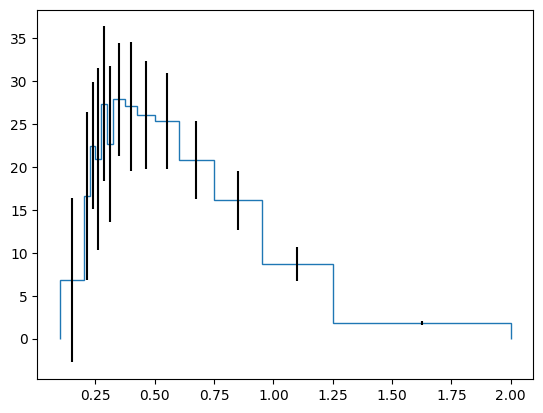

In [9]:
data = np.loadtxt("data_1d_pmu.txt")
data_bins = np.loadtxt("bins_1d_pmu.txt")
data_cov = np.loadtxt("cov_1d_pmu.txt", delimiter=",")
data_ac = np.loadtxt("ac_1d_pmu.txt", delimiter=",")
print(data)
print(data_bins)
plt.hist(data_bins[:-1], bins=data_bins, weights=data, histtype="step")
plt.errorbar(data_bins[:-1] +(data_bins[1:]-data_bins[:-1])/2, data,yerr=[data_cov[i][i] for i in range(len(data_cov))],ecolor='k', linestyle='') 
plt.show()

In [6]:
evt = hm3.GenEvent()


In [7]:
# read the first 5 events and print everything in them
rdr = nhm.Reader("neut.EDRMF.DCC5D.MicroBooNE.250000Ev.hepmc3.gz")
while True: #slightly ugly reading paradigm that is outside of my control
    rdr.read_event(evt)
    if rdr.failed():
        break

    if evt.event_number() > 5:
        break
    
    hm3.Print.content(evt)

--------------------------------
--------- EVENT CONTENT --------
--------------------------------

Weights (1): 
 1Attributes:
0: NEUT.modene
0: NEUT.passthrough.doubles
0: NEUT.passthrough.fields.doubles
0: NEUT.passthrough.fields.floats
0: NEUT.passthrough.fields.ints
0: NEUT.passthrough.floats
0: NEUT.passthrough.ints
0: lab_pos
2: remnant_particle_number
0: signal_process_id
0: tot_xs
GenParticlePtr (8)
GenParticle:   1 PDGID: 1000180400 (P,E)=+0.00e+00,+0.00e+00,+0.00e+00,+0.00e+00 Stat: 20 PV: 0 EV: -1 Attr: 0
GenParticle:   2 PDGID: 2009900000 (P,E)=+0.00e+00,+0.00e+00,+0.00e+00,+0.00e+00 Stat: 3 PV: -1 EV: -2 Attr: 1 remnant_particle_number=1000170390
GenParticle:   3 PDGID: 2009900000 (P,E)=+0.00e+00,+0.00e+00,+0.00e+00,+0.00e+00 Stat: 1 PV: -2 EV: 0 Attr: 0
GenParticle:   4 PDGID:    14 (P,E)=+0.00e+00,+0.00e+00,+1.70e+03,+1.70e+03 Stat: 4 PV: 0 EV: -3 Attr: 0
GenParticle:   5 PDGID:  2212 (P,E)=-6.62e+01,-8.22e+00,-9.19e+00,+9.41e+02 Stat: 21 PV: -1 EV: -3 Attr: 0
GenPartic

In [8]:
muon_momentum_list = []
rdr = nhm.Reader("neut.EDRMF.DCC5D.MicroBooNE.250000Ev.hepmc3.gz")
while True:
    rdr.read_event(evt)    
    if rdr.failed():
        break
    
    # only care about events that has exactly 1 outgoing muon
    if not ps.event.has_exact_out_part(evt, ps.pdg.kMuon, 1):
        continue
    
    # grab the muon particle object
    muon = ps.event.hm_out_part(evt, ps.pdg.kMuon)
    # get its momentum in GeV/c
    muon_momentum = ps.p3mod(muon) / ps.unit.GeV_c
    muon_momentum_list.append(muon_momentum)

KeyboardInterrupt: 

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sp

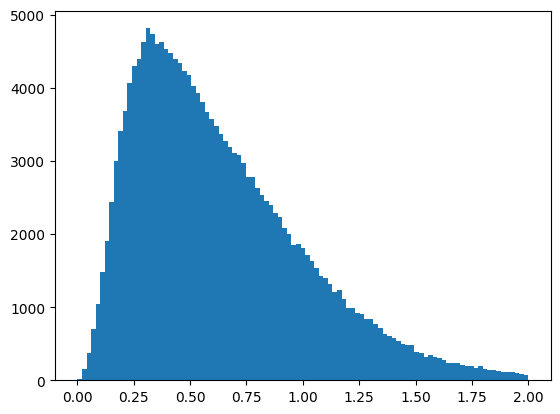

In [9]:
plt.hist(muon_momentum_list, bins=np.linspace(0,2,100))
plt.show()

# Analysis Structure

In [4]:
def passes_selection(evt):
    # only care about events that has exactly 1 outgoing muon
    if not ps.event.has_exact_out_part(evt, ps.pdg.kMuon, 1):
        return False
    elif ps.event.all_out_part(evt, ps.pdg.kPiZero) != []:
        return False
    elif ps.part.filter(ps.p3mod > 70 * ps.unit.MeV, ps.event.all_out_part(evt, ps.pdg.kPiMinus)) !=[]: # no charged pions with p>70 MeV
        return False
    elif ps.part.filter(ps.p3mod > 70 * ps.unit.MeV, ps.event.all_out_part(evt, ps.pdg.kPiPlus)) !=[]:  # no charged pions with p>70 MeV
        return False
    elif ps.part.filter((ps.p3mod < 0.1 * ps.unit.GeV),ps.event.all_out_part(evt, ps.pdg.kMuon)) != [] or ps.part.filter( (ps.p3mod > 2 * ps.unit.GeV),ps.event.all_out_part(evt, ps.pdg.kMuon)) != []:
        return False
    # add other cuts here
    #
    #
    return True
ps.pdg.kPiPlus
def projection(evt):
    # grab the muon particle object
    muon = ps.event.hm_out_part(evt, ps.pdg.kMuon)
    # get its momentum in GeV/c
    return ps.p3mod(muon) / ps.unit.GeV_c

observable_list = []
evt = hm3.GenEvent()
rdr = nhm.Reader("neut.SF.RS1pi.MicroBooNE.500000Ev.hepmc3.gz")
while True:
    rdr.read_event(evt)    
    if rdr.failed():
        break
    
    if not passes_selection(evt):
        continue
    
    observable_list.append(projection(evt))

In [5]:
def projection_cos_theta(evt):
    muon = ps.event.hm_out_part(evt, ps.pdg.kMuon)
    return ps.costheta(muon)
    

[0.1   0.2   0.225 0.25  0.275 0.3   0.325 0.375 0.425 0.5   0.6   0.75
 0.95  1.25  2.   ]
[0.1   0.025 0.025 0.025 0.025 0.025 0.05  0.05  0.075 0.1   0.15  0.2
 0.3   0.75 ]


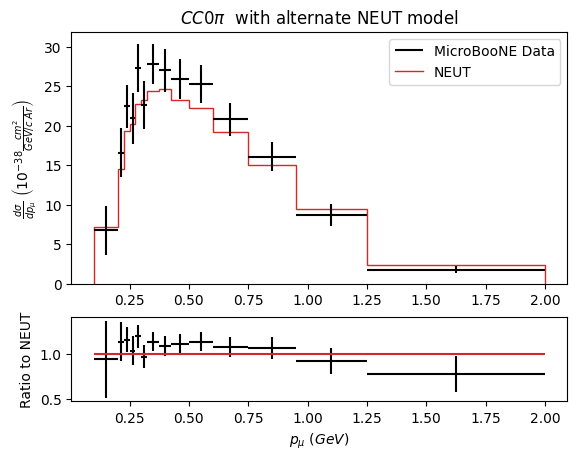

In [14]:

totalNumberOfEventsInFile = 500000.0
bins = data_bins # 50 uniform bins between 0 and 5.
counts, bins = np.histogram(observable_list, bins=bins)
counts = counts * 40.*0.0102368454411126/totalNumberOfEventsInFile
counts = counts * 1E2 # convert pb/Atom -> 1E-38 cm^2 per atom
# print(counts)
# counts = [float(c) for c in counts]
# # scale the prediction to a cross section according to the average cross section reported by the simulation
# counts = [c*40*0.0102368454411126/(totalNumberOfEventsInFile) for c in counts]#250000 in the original file
#counts = [np.dot(data_ac[i],counts) for i in range(len(counts))]
widths = bins[1:] - bins[:-1]
counts_smeared_aft = counts / widths
counts_smeared_aft = data_ac @ counts_smeared_aft

counts_smeared_bef = data_ac @ counts 
counts_smeared_bef = counts_smeared_bef /widths
print(bins)
print(widths)

fig, axs = plt.subplots(2, 1, height_ratios=[3, 1])
data_err = [data_cov[i][i]**(1/2) for i in range(len(data_cov))]
axs[0].errorbar(data_bins[:-1] +(data_bins[1:]-data_bins[:-1])/2, data,yerr=[data_cov[i][i]**(1/2) for i in range(len(data_cov))],ecolor='k', linestyle='')
axs[0].hlines(data,bins[:-1],bins[1:], color="k", label="MicroBooNE Data")
axs[0].stairs(counts_smeared_bef, bins, label="NEUT", color="C3")
#plt.gca().stairs(counts_smeared_aft, bins, label="Smeared after width division")
#plt.hist(data_bins[:-1], bins=data_bins, weights=data, histtype="step", label="MicroBooNE Data", facecolor="k", color="k", zorder=0)
axs[0].set_ylabel(r'$ \frac{d \sigma}{d p_{\mu}}  \ \left(10^{-38} \frac{cm^2}{GeV/c \ Ar} \right)$')
axs[0].legend()


data_err = [data_cov[i][i]**(1/2) for i in range(len(data_cov))]
axs[1].errorbar(data_bins[:-1] +(data_bins[1:]-data_bins[:-1])/2, data/counts_smeared_bef,yerr=[data_cov[i][i]**(1/2)/counts_smeared_bef[i] for i in range(len(data_cov))],ecolor='k', linestyle='')
axs[1].hlines(data/counts_smeared_bef,bins[:-1],bins[1:], color="k", label="MicroBooNE Data")
axs[1].hlines(counts_smeared_bef/counts_smeared_bef, bins[:-1],bins[1:], label="NEUT (Previous)", color="C3")
#plt.gca().stairs(counts_smeared_aft, bins, label="Smeared after width division")
#plt.hist(data_bins[:-1], bins=data_bins, weights=data, histtype="step", label="MicroBooNE Data", facecolor="k", color="k", zorder=0)
axs[1].set_ylabel(r'Ratio to NEUT')


axs[1].set_xlabel(r'$ p_{\mu} \ (GeV)$')
axs[0].set_title(r"$ CC 0 \pi \ $ with alternate NEUT model")
plt.show()

In [25]:
chi_sq = sum(((counts_smeared_bef - data)**2)/np.array(data_err)**2)
chi_sq

np.float64(12.099875049984377)

In [17]:
chi_sq_op  = sum(((data - counts_smeared_bef)/)**2)
chi_sq_op

np.float64(0.2767547421640084)

In [19]:
data_ct = np.loadtxt("data_1d_costhetamu.txt")
bins_ct = np.loadtxt("bins_1d_ctmu.txt")
ct_cov = np.loadtxt("cov_1d_costhetamu.txt", delimiter=",")
ct_ac = np.loadtxt("ac_1d_costhetamu.txt", delimiter=",")

In [17]:
observable_list_ct = []
evt = hm3.GenEvent()
rdr = nhm.Reader("neut.EDRMF.DCC5D.MicroBooNE.500000Ev.hepmc3.gz")
while True:
    rdr.read_event(evt)    
    if rdr.failed():
        break
    
    if not passes_selection(evt):
        continue
    
    observable_list_ct.append(projection_cos_theta(evt))

[0.225 0.125 0.1   0.1   0.075 0.075 0.1   0.075 0.075 0.075 0.075 0.075
 0.075 0.075 0.075 0.075 0.075 0.075 0.05  0.05  0.05  0.05  0.025 0.025
 0.025 0.025 0.025 0.025 0.025]
30


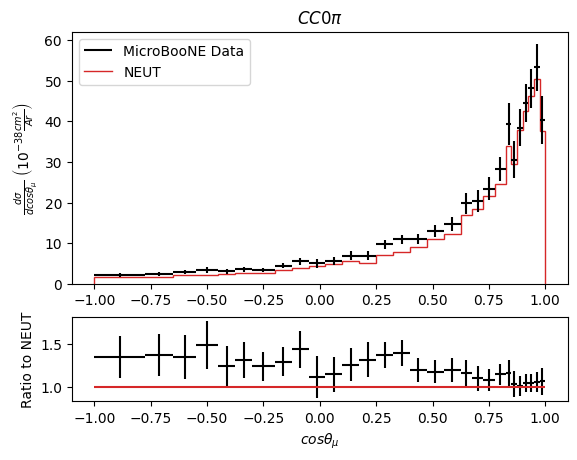

In [23]:

totalNumberOfEventsInFile = 500000.0
counts_ct, bins_ct = np.histogram(observable_list_ct, bins=bins_ct)
counts_ct = counts_ct * 40.*0.0102368454411126/totalNumberOfEventsInFile
counts_ct = counts_ct * 1E2 # convert pb/Atom -> 1E-38 cm^2 per atom
# print(counts)
# counts = [float(c) for c in counts]
# # scale the prediction to a cross section according to the average cross section reported by the simulation
# counts = [c*40*0.0102368454411126/(totalNumberOfEventsInFile) for c in counts]#250000 in the original file
#counts = [np.dot(data_ac[i],counts) for i in range(len(counts))]
widths_ct = bins_ct[1:] - bins_ct[:-1]
print(widths_ct)

counts_smeared_bef_ct = ct_ac @ counts_ct 
counts_smeared_bef_ct = counts_smeared_bef_ct /widths_ct

fig, axs = plt.subplots(2, 1, height_ratios=[3, 1])
ct_err = [ct_cov[i][i]**(1/2) for i in range(len(ct_cov))]
axs[0].errorbar(bins_ct[:-1] +(bins_ct[1:]-bins_ct[:-1])/2, data_ct,yerr=ct_err,ecolor='k', linestyle='')
axs[0].hlines(data_ct,bins_ct[:-1],bins_ct[1:], color="k", label="MicroBooNE Data")
axs[0].stairs(counts_smeared_bef_ct, bins_ct, label="NEUT", color="C3")
#plt.gca().stairs(counts_smeared_aft, bins, label="Smeared after width division")
#plt.hist(data_bins[:-1], bins=data_bins, weights=data, histtype="step", label="MicroBooNE Data", facecolor="k", color="k", zorder=0)
axs[0].set_ylabel(r'$ \frac{d \sigma}{dcos\theta_{\mu}}  \ \left(10^{-38} \frac{cm^2}{Ar} \right)$')
axs[0].legend()
print(len(bins_ct))

axs[1].errorbar(bins_ct[:-1] +(bins_ct[1:]-bins_ct[:-1])/2, data_ct/counts_smeared_bef_ct,yerr=ct_err/counts_smeared_bef_ct,ecolor='k', linestyle='')
axs[1].hlines(data_ct/counts_smeared_bef_ct,bins_ct[:-1],bins_ct[1:], color="k", label="MicroBooNE Data")
axs[1].hlines(counts_smeared_bef_ct/counts_smeared_bef_ct, bins_ct[:-1],bins_ct[1:], label="NEUT", color="C3")
#plt.gca().stairs(counts_smeared_aft, bins, label="Smeared after width division")
#plt.hist(data_bins[:-1], bins=data_bins, weights=data, histtype="step", label="MicroBooNE Data", facecolor="k", color="k", zorder=0)
axs[1].set_ylabel(r'Ratio to NEUT')


axs[1].set_xlabel(r'$ cos\theta_{\mu}$')
axs[0].set_title(r"$ CC 0 \pi \ $")
plt.show()

In [24]:
chi_sq_ct = sum(((counts_smeared_bef_ct - data_ct)**2)/np.array(ct_err)**2)
chi_sq_ct/29

np.float64(1.77294890143215)

In [26]:
counts_smeared_bef.tofile("neutNewP_mu.txt", "\n")

In [27]:
counts_smeared_bef_ct.tofile("neutNew_cos_theta_mu.txt", "\n")